# Instagram

## Import Libries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv(r"Instagram_dataset\Batch C2 Instagram_Analytics.csv")
df  

,post_id,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category
0,IG0000001,Reel,31627,7559,4530,6393,615036,1007750,1340,3,899,Home Feed,4.97,Technology
1,IG0000002,Photo,63206,3490,1680,6809,1237071,1345900,1351,20,805,Hashtags,5.59,Fitness
2,IG0000003,Reel,94373,3727,1761,8367,1127470,1305369,242,24,758,Reels Feed,8.29,Beauty
3,IG0000004,Reel,172053,7222,2875,9290,764030,897874,446,11,402,External,21.32,Music
4,IG0000005,Video,99646,2703,4444,9746,7004,495406,1905,8,155,Profile,23.52,Technology
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,IG0029995,Video,46046,8354,3847,11095,597992,820688,1254,18,124,Reels Feed,8.45,Travel
29995,IG0029996,Carousel,67711,3266,458,12380,1908094,2218288,1427,4,310,Hashtags,3.78,Beauty
29996,IG0029997,Photo,52326,7328,3687,7619,1984066,2447893,713,4,223,Explore,2.90,Photography
29997,IG0029998,Carousel,158113,5890,2573,6329,1984709,2001092,1341,22,978,Explore,8.64,Technology


# Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   post_id           29999 non-null  object 
 1   media_type        29999 non-null  object 
 2   likes             29999 non-null  int64  
 3   comments          29999 non-null  int64  
 4   shares            29999 non-null  int64  
 5   saves             29999 non-null  int64  
 6   reach             29999 non-null  int64  
 7   impressions       29999 non-null  int64  
 8   caption_length    29999 non-null  int64  
 9   hashtags_count    29999 non-null  int64  
 10  followers_gained  29999 non-null  int64  
 11  traffic_source    29999 non-null  object 
 12  engagement_rate   29999 non-null  float64
 13  content_category  29999 non-null  object 
dtypes: float64(1), int64(9), object(4)
memory usage: 3.2+ MB


In [ ]:
df.isnull().sum()

post_id             0
media_type          0
likes               0
comments            0
shares              0
saves               0
reach               0
impressions         0
caption_length      0
hashtags_count      0
followers_gained    0
traffic_source      0
engagement_rate     0
content_category    0
dtype: int64

In [ ]:
df

,post_id,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category
0,IG0000001,Reel,31627,7559,4530,6393,615036,1007750,1340,3,899,Home Feed,4.97,Technology
1,IG0000002,Photo,63206,3490,1680,6809,1237071,1345900,1351,20,805,Hashtags,5.59,Fitness
2,IG0000003,Reel,94373,3727,1761,8367,1127470,1305369,242,24,758,Reels Feed,8.29,Beauty
3,IG0000004,Reel,172053,7222,2875,9290,764030,897874,446,11,402,External,21.32,Music
4,IG0000005,Video,99646,2703,4444,9746,7004,495406,1905,8,155,Profile,23.52,Technology
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,IG0029995,Video,46046,8354,3847,11095,597992,820688,1254,18,124,Reels Feed,8.45,Travel
29995,IG0029996,Carousel,67711,3266,458,12380,1908094,2218288,1427,4,310,Hashtags,3.78,Beauty
29996,IG0029997,Photo,52326,7328,3687,7619,1984066,2447893,713,4,223,Explore,2.90,Photography
29997,IG0029998,Carousel,158113,5890,2573,6329,1984709,2001092,1341,22,978,Explore,8.64,Technology


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df

,post_id,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category
0,IG0000001,Reel,31627,7559,4530,6393,615036,1007750,1340,3,899,Home Feed,4.97,Technology
1,IG0000002,Photo,63206,3490,1680,6809,1237071,1345900,1351,20,805,Hashtags,5.59,Fitness
2,IG0000003,Reel,94373,3727,1761,8367,1127470,1305369,242,24,758,Reels Feed,8.29,Beauty
3,IG0000004,Reel,172053,7222,2875,9290,764030,897874,446,11,402,External,21.32,Music
4,IG0000005,Video,99646,2703,4444,9746,7004,495406,1905,8,155,Profile,23.52,Technology
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,IG0029995,Video,46046,8354,3847,11095,597992,820688,1254,18,124,Reels Feed,8.45,Travel
29995,IG0029996,Carousel,67711,3266,458,12380,1908094,2218288,1427,4,310,Hashtags,3.78,Beauty
29996,IG0029997,Photo,52326,7328,3687,7619,1984066,2447893,713,4,223,Explore,2.90,Photography
29997,IG0029998,Carousel,158113,5890,2573,6329,1984709,2001092,1341,22,978,Explore,8.64,Technology


In [ ]:
le = LabelEncoder()

obj_cols = df.select_dtypes(include=['object']).columns

for col in obj_cols:
    df[col] = le.fit_transform(df[col])

# EDA

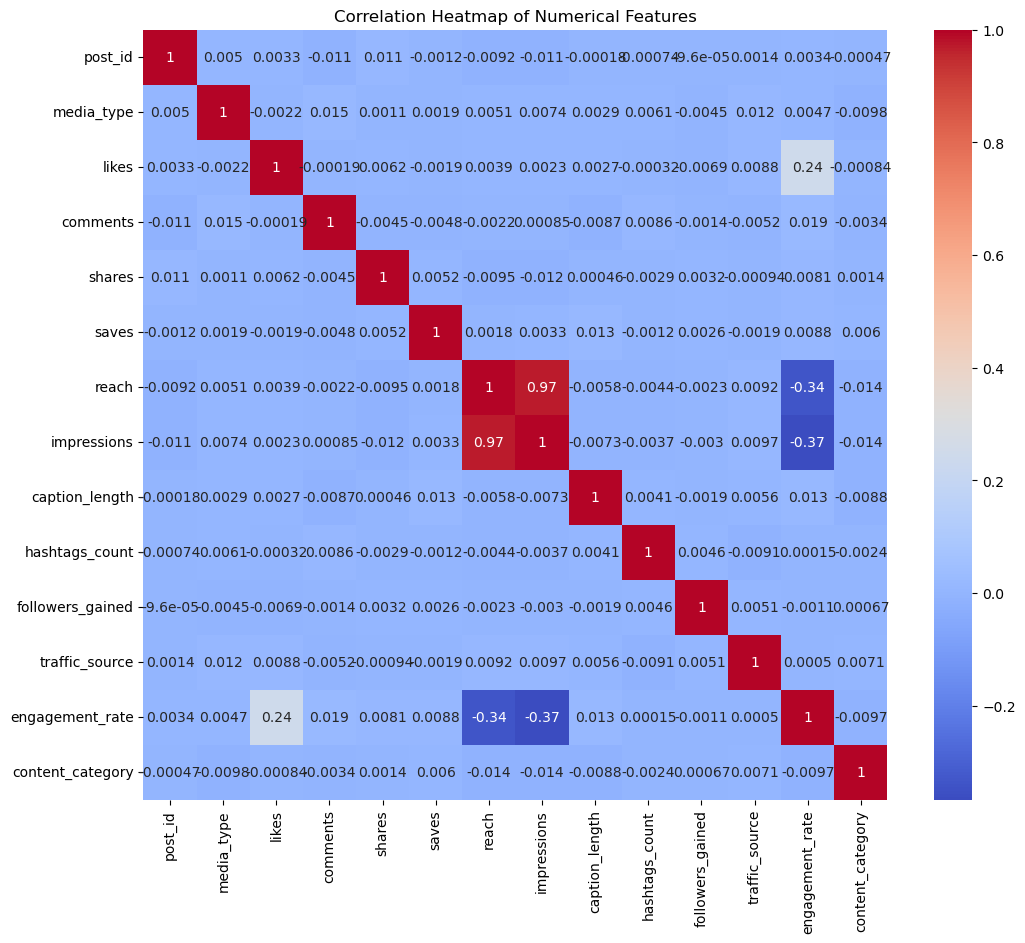

In [ ]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

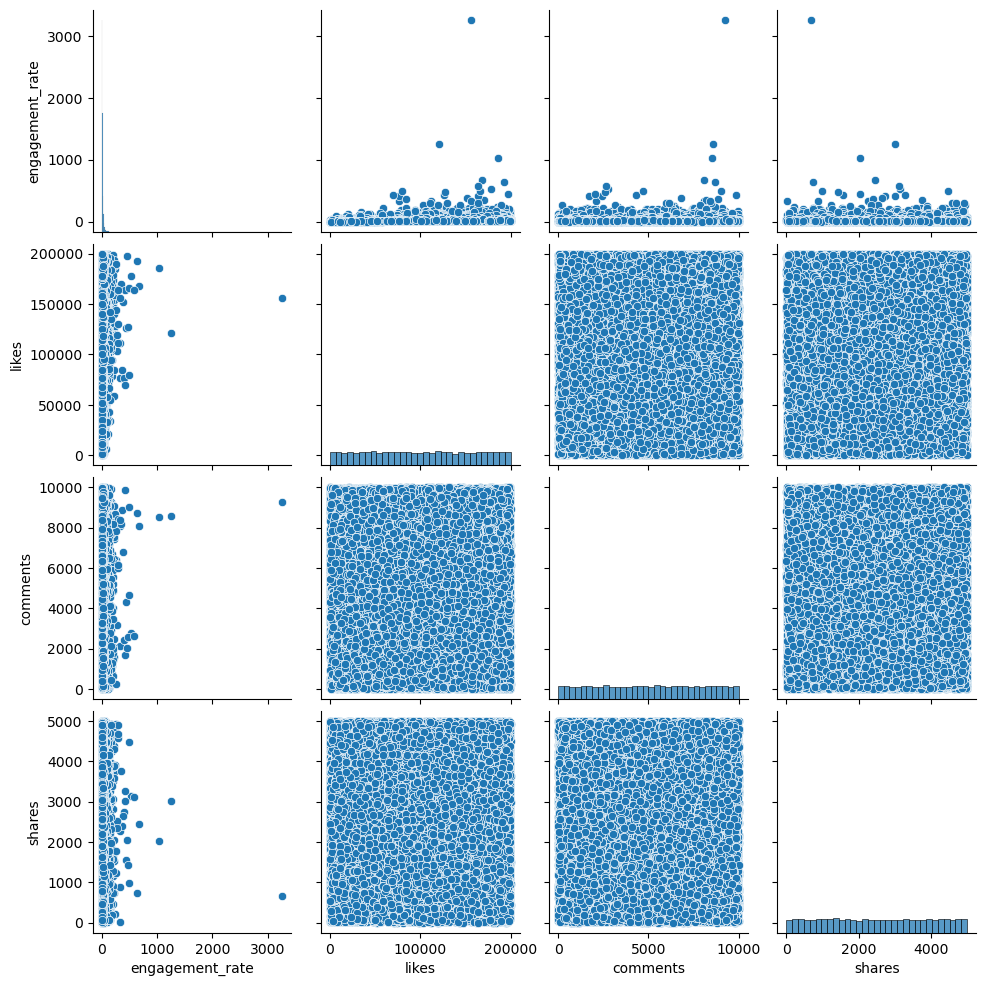

In [ ]:
selected_cols = ['engagement_rate', 'likes', 'comments', 'shares']

sns.pairplot(df[selected_cols])
plt.show()


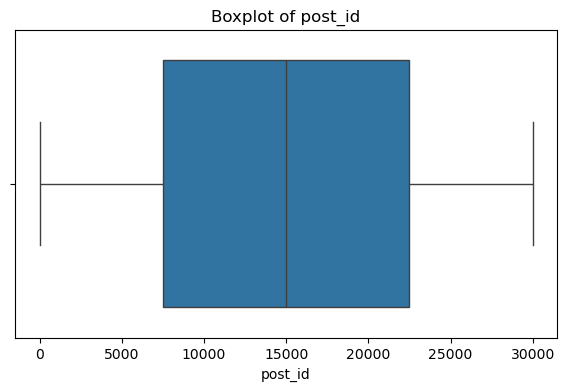

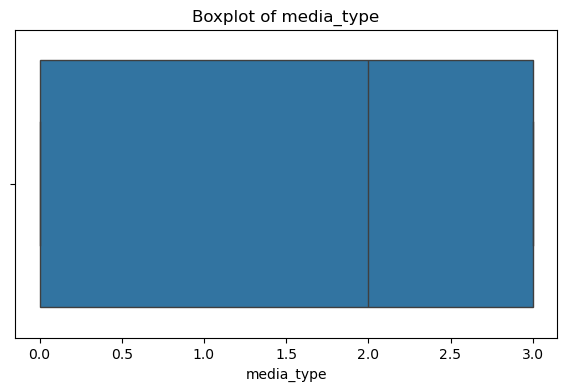

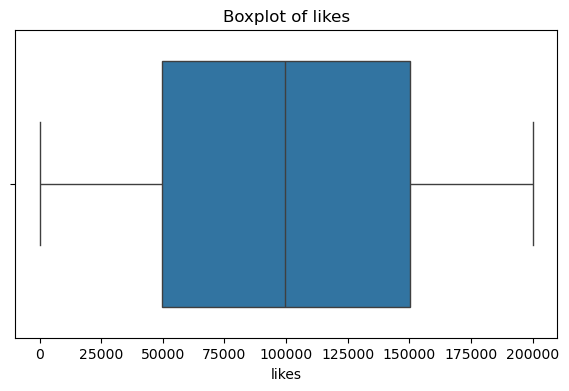

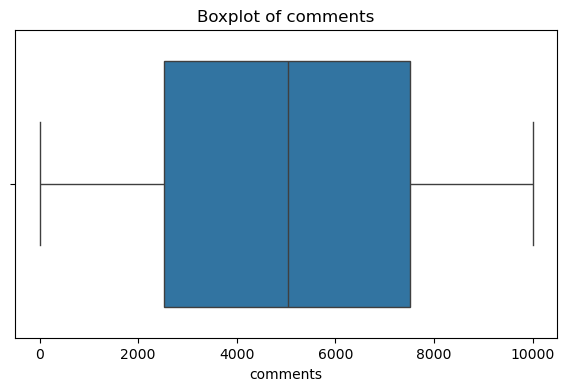

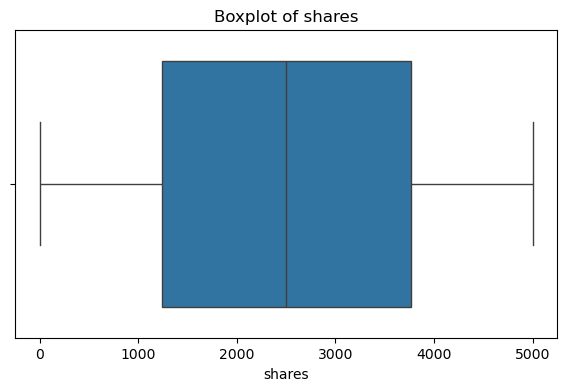

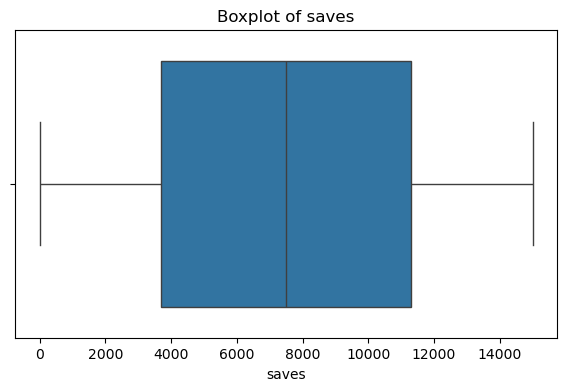

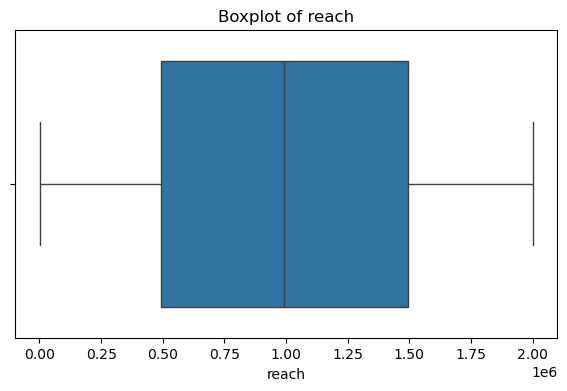

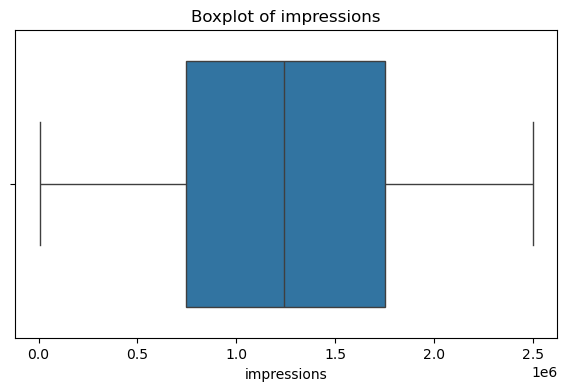

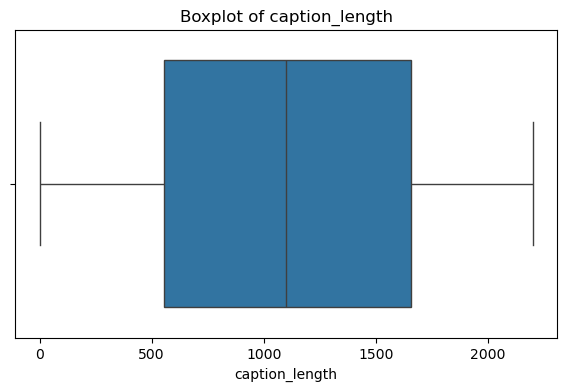

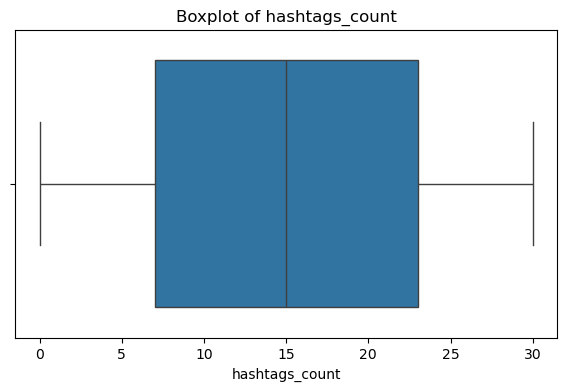

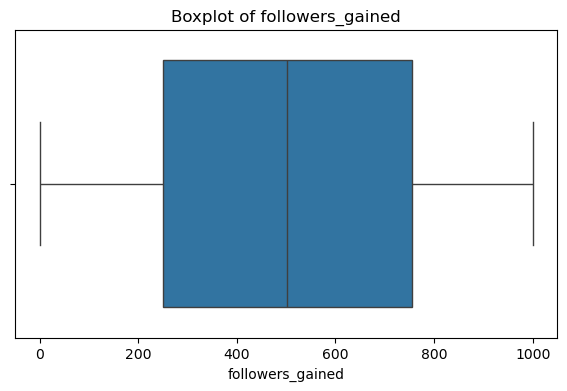

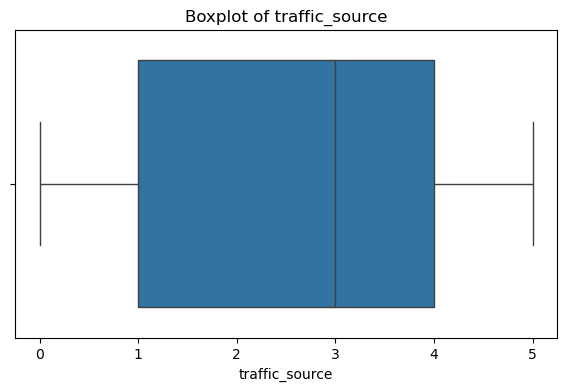

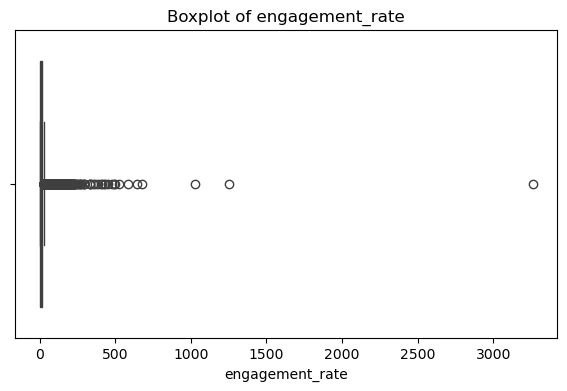

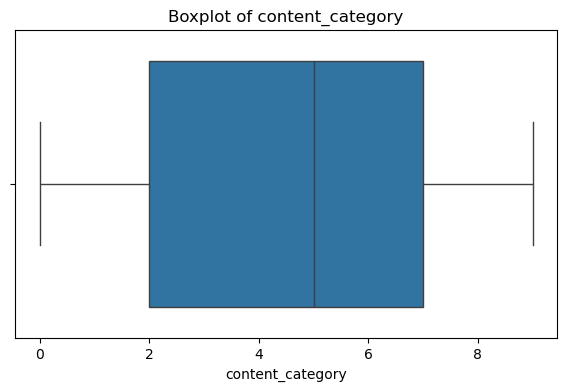

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
df

,post_id,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category
0,0,2,31627,7559,4530,6393,615036,1007750,1340,3,899,3,4.97,8
1,1,1,63206,3490,1680,6809,1237071,1345900,1351,20,805,2,5.59,3
2,2,2,94373,3727,1761,8367,1127470,1305369,242,24,758,5,8.29,0
3,3,2,172053,7222,2875,9290,764030,897874,446,11,402,1,21.32,6
4,4,3,99646,2703,4444,9746,7004,495406,1905,8,155,4,23.52,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,29994,3,46046,8354,3847,11095,597992,820688,1254,18,124,5,8.45,9
29995,29995,0,67711,3266,458,12380,1908094,2218288,1427,4,310,2,3.78,0
29996,29996,1,52326,7328,3687,7619,1984066,2447893,713,4,223,0,2.90,7
29997,29997,0,158113,5890,2573,6329,1984709,2001092,1341,22,978,0,8.64,8


In [ ]:
from sklearn.preprocessing import StandardScaler
target_col = 'engagement_rate'
cols_to_scale = [col for col in df.columns if col != target_col]

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
df[target_col] = df[target_col]

In [ ]:
df

,post_id,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category
0,-1.731993,0.445568,-1.179271,0.879815,1.399636,-0.252069,-0.660329,-0.400144,0.372478,-1.319995,1.366746,0.287651,4.97,1.218230
1,-1.731878,-0.447682,-0.633912,-0.528945,-0.568194,-0.156491,0.416264,0.166193,0.389775,0.567706,1.043009,-0.300132,5.59,-0.527661
2,-1.731762,0.445568,-0.095668,-0.446891,-0.512266,0.201466,0.226571,0.098312,-1.353989,1.011871,0.881140,1.463219,8.29,-1.575195
3,-1.731647,0.445568,1.245839,0.763139,0.256914,0.413529,-0.402456,-0.584165,-1.033225,-0.431665,-0.344927,-0.887916,21.32,0.519874
4,-1.731531,1.338817,-0.004605,-0.801418,1.340256,0.518297,-1.712686,-1.258223,1.260870,-0.764789,-1.195598,0.875435,23.52,1.218230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,1.731531,1.338817,-0.930259,1.155058,0.928047,0.828236,-0.689828,-0.713437,0.237254,0.345624,-1.302362,1.463219,8.45,1.567408
29995,1.731647,-1.340931,-0.556112,-0.606498,-1.411944,1.123470,1.577643,1.627278,0.509275,-1.208954,-0.661776,-0.300132,3.78,-1.575195
29996,1.731762,-0.447682,-0.821806,0.799838,0.817573,0.029610,1.709133,2.011823,-0.613401,-1.208954,-0.961405,-1.475700,2.90,0.869052
29997,1.731878,-1.340931,1.005100,0.301977,0.048393,-0.266773,1.710246,1.263516,0.374051,0.789789,1.638823,-1.475700,8.64,1.218230


# Spliting Training and Testing

In [ ]:
x = df.drop(['engagement_rate'],axis=1)
x

,post_id,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,content_category
0,-1.731993,0.445568,-1.179271,0.879815,1.399636,-0.252069,-0.660329,-0.400144,0.372478,-1.319995,1.366746,0.287651,1.218230
1,-1.731878,-0.447682,-0.633912,-0.528945,-0.568194,-0.156491,0.416264,0.166193,0.389775,0.567706,1.043009,-0.300132,-0.527661
2,-1.731762,0.445568,-0.095668,-0.446891,-0.512266,0.201466,0.226571,0.098312,-1.353989,1.011871,0.881140,1.463219,-1.575195
3,-1.731647,0.445568,1.245839,0.763139,0.256914,0.413529,-0.402456,-0.584165,-1.033225,-0.431665,-0.344927,-0.887916,0.519874
4,-1.731531,1.338817,-0.004605,-0.801418,1.340256,0.518297,-1.712686,-1.258223,1.260870,-0.764789,-1.195598,0.875435,1.218230
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,1.731531,1.338817,-0.930259,1.155058,0.928047,0.828236,-0.689828,-0.713437,0.237254,0.345624,-1.302362,1.463219,1.567408
29995,1.731647,-1.340931,-0.556112,-0.606498,-1.411944,1.123470,1.577643,1.627278,0.509275,-1.208954,-0.661776,-0.300132,-1.575195
29996,1.731762,-0.447682,-0.821806,0.799838,0.817573,0.029610,1.709133,2.011823,-0.613401,-1.208954,-0.961405,-1.475700,0.869052
29997,1.731878,-1.340931,1.005100,0.301977,0.048393,-0.266773,1.710246,1.263516,0.374051,0.789789,1.638823,-1.475700,1.218230


In [ ]:
y = df['engagement_rate']
y


0         4.97
1         5.59
2         8.29
3        21.32
4        23.52
         ...  
29994     8.45
29995     3.78
29996     2.90
29997     8.64
29998     5.02
Name: engagement_rate, Length: 29999, dtype: float64

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=77)

In [ ]:
x_train.shape

(23999, 13)

In [ ]:
y_train.shape

(23999,)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

algorithm_names = []
MAE_list = []
MSE_list = []
RMSE_list = []
R2_list = []

def calculateRegressionMetrics(algorithm, predict, testY):

    mae = mean_absolute_error(testY, predict)
    mse = mean_squared_error(testY, predict)
    rmse = np.sqrt(mse)
    r2 = r2_score(testY, predict)

    
    print(f"{algorithm} Mean Absolute Error (MAE): {mae:.2f}")
    print(f"{algorithm} Mean Squared Error (MSE): {mse:.2f}")
    print(f"{algorithm} Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"{algorithm} R2 Score: {r2:.2f}")


    algorithm_names.append(algorithm)
    MAE_list.append(mae)
    MSE_list.append(mse)
    RMSE_list.append(rmse)
    R2_list.append(r2)

    plt.figure(figsize=(7, 7))
    plt.scatter(testY, predict, color='blue', alpha=0.6)
    plt.plot([min(testY), max(testY)], [min(testY), max(testY)], color='red', linestyle='--', linewidth=2)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{algorithm} Predicted vs Actual Values")
    plt.grid(True)
    plt.show()


# Model Building and Training

## KNN Regressor

C:\Users\spoor\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


KNN Regressor Mean Absolute Error (MAE): 4.47
KNN Regressor Mean Squared Error (MSE): 527.33
KNN Regressor Root Mean Squared Error (RMSE): 22.96
KNN Regressor R2 Score: 0.23


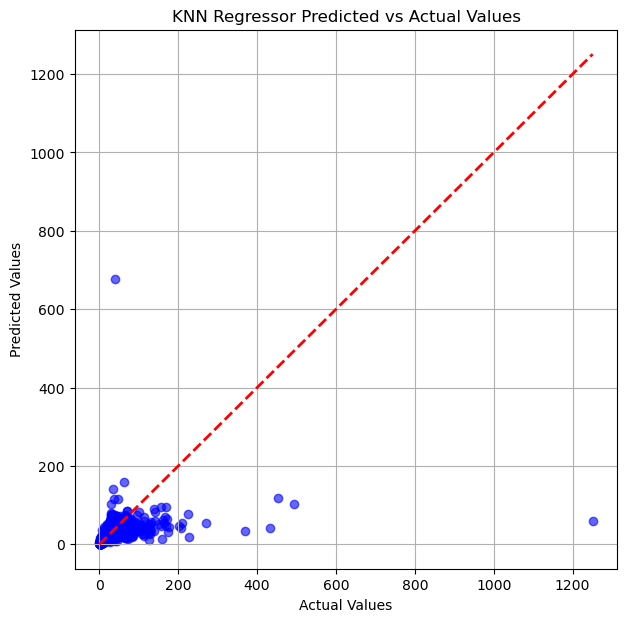

In [ ]:
import os
import joblib
from sklearn.neighbors import KNeighborsRegressor
model = 'model/knn_regressor.pkl'
if os.path.exists(model):
    knn_regressor = joblib.load(model)
    predict = knn_regressor.predict(x_test)
    calculateRegressionMetrics("KNN Regressor", predict, y_test)
else:
    knn_regressor = KNeighborsRegressor()
    knn_regressor.fit(x_train, y_train)
    predict = knn_regressor.predict(x_test)
    joblib.dump(knn_regressor, model)
    print("KNN Regressor trained and model weights saved.")
    calculateRegressionMetrics("KNN Regressor", predict, y_test)

## Linear Regression

C:\Users\spoor\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Linear Regressor Mean Absolute Error (MAE): 7.79
Linear Regressor Mean Squared Error (MSE): 510.76
Linear Regressor Root Mean Squared Error (RMSE): 22.60
Linear Regressor R2 Score: 0.25


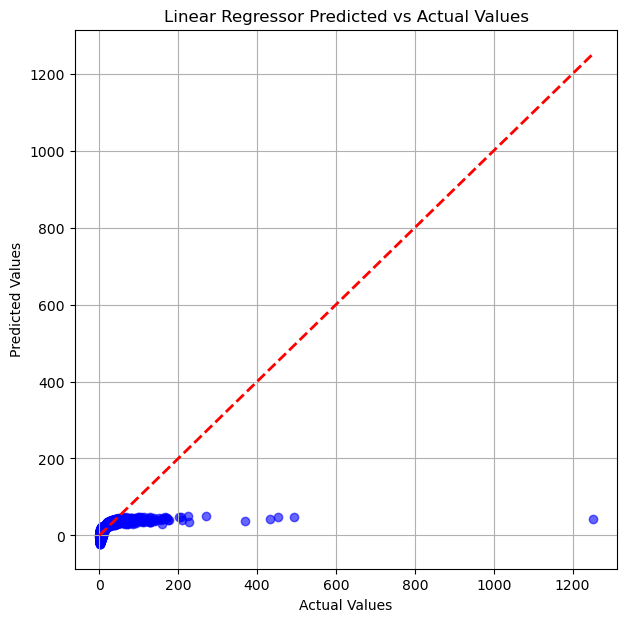

In [ ]:
import os
import joblib
from sklearn.linear_model import LinearRegression

model = 'model/linear_regressor.pkl'
if os.path.exists(model):
    linear_regressor = joblib.load(model)
    predict = linear_regressor.predict(x_test)
    calculateRegressionMetrics("Linear Regressor", predict, y_test)
else:
    linear_regressor = LinearRegression()
    linear_regressor.fit(x_train, y_train)
    predict = linear_regressor.predict(x_test)
    joblib.dump(linear_regressor, model)
    print("Linear Regressor trained and model weights saved.")
    calculateRegressionMetrics("Linear Regressor", predict, y_test)

## Random Forest Regressor

Random Forest Regressor trained and model weights saved.
Random Forest Regressor Mean Absolute Error (MAE): 0.60
Random Forest Regressor Mean Squared Error (MSE): 161.66
Random Forest Regressor Root Mean Squared Error (RMSE): 12.71
Random Forest Regressor R2 Score: 0.76


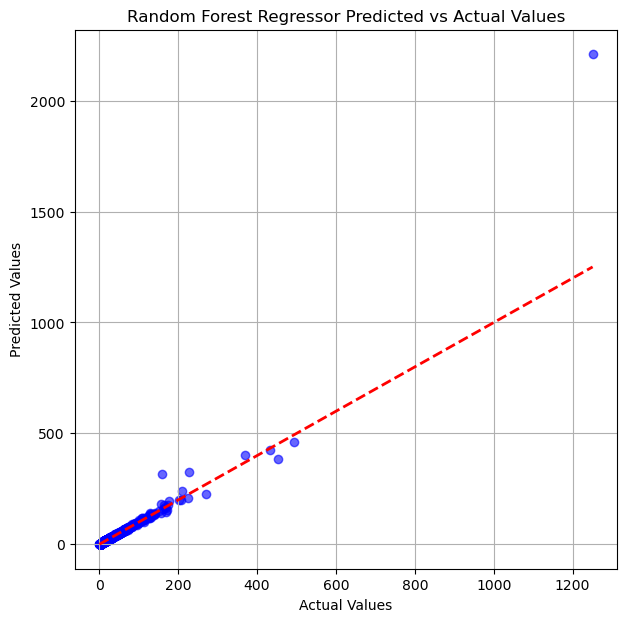

In [ ]:
import os
import joblib
from sklearn.ensemble import RandomForestRegressor

model = 'model/random_forest_regressor.pkl'

if os.path.exists(model):
    rf_regressor = joblib.load(model)
    predict = rf_regressor.predict(x_test)
    calculateRegressionMetrics("Random Forest Regressor", predict, y_test)
else:
    rf_regressor = RandomForestRegressor(n_estimators=200, random_state=42)
    rf_regressor.fit(x_train, y_train)
    predict = rf_regressor.predict(x_test)
    joblib.dump(rf_regressor, model)
    print("Random Forest Regressor trained and model weights saved.")
    calculateRegressionMetrics("Random Forest Regressor", predict, y_test)


## Decision tree Regressor

C:\Users\spoor\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Decision Tree Regressor Mean Absolute Error (MAE): 0.96
Decision Tree Regressor Mean Squared Error (MSE): 18.97
Decision Tree Regressor Root Mean Squared Error (RMSE): 4.36
Decision Tree Regressor R2 Score: 0.97


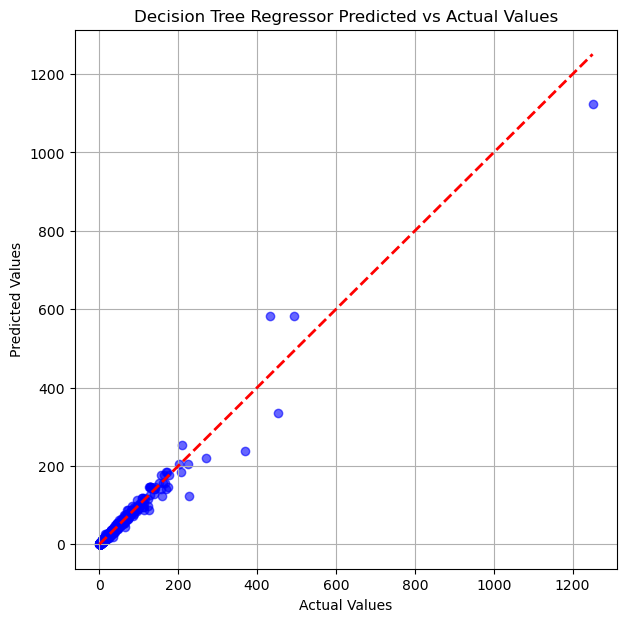

In [ ]:
from sklearn.tree import DecisionTreeRegressor
import os
import joblib

model = 'model/dtr_regressor1.pkl'

if os.path.exists(model):
    dt_regressor = joblib.load(model)
    predict = dt_regressor.predict(x_test)
    calculateRegressionMetrics("Decision Tree Regressor", predict, y_test)
else:
    dt_regressor = DecisionTreeRegressor(max_depth=25,min_samples_split=15,min_samples_leaf=5,max_features=None,
    ccp_alpha=0.001,random_state=77)
    dt_regressor.fit(x_train, y_train)
    predict = dt_regressor.predict(x_test)
    joblib.dump(dt_regressor, model)
    print("Decision Tree Regressor trained and model weights saved.")
    calculateRegressionMetrics("Decision Tree Regressor", predict, y_test)


# Comparison Matrix

In [ ]:
columns = ["algorithm_name", "MAE", "MSE", "RMSE", "R2"]

values = []
for i in range(len(algorithm_names)):
    values.append([
        algorithm_names[i],
        round(MAE_list[i], 2),
        round(MSE_list[i], 2),
        round(RMSE_list[i], 2),
        round(R2_list[i], 2)
    ])

comparison_df = pd.DataFrame(values, columns=columns)
comparison_df = comparison_df.sort_values(by="R2", ascending=False)
print("\nFinal Regression Model Comparison Table:\n")
print(comparison_df)


Final Regression Model Comparison Table:

            algorithm_name   MAE     MSE   RMSE    R2
3  Decision Tree Regressor  0.96   18.97   4.36  0.97
2  Random Forest Regressor  0.60  161.66  12.71  0.76
1         Linear Regressor  7.79  510.76  22.60  0.25
0            KNN Regressor  4.47  527.33  22.96  0.23


# Comparison Graph

In [ ]:

def plot_metric(metric_name):
    values = []
    for i in range(len(algorithm_names)):
        values.append([algorithm_names[i], MAE_list[i], MSE_list[i], RMSE_list[i], R2_list[i]])
    
    results_df = pd.DataFrame(values, columns=columns)

    if metric_name not in results_df.columns:
        print(f"Error: Metric '{metric_name}' not found in results_df.")
        return

    plt.figure(figsize=(8, 6))
    ax = sns.barplot(
        x="algorithm_name",
        y=metric_name,
        data=results_df,
        palette="viridis"
    )

    # Add values on top of bars
    for p in ax.patches:
        value = p.get_height()
        ax.annotate(
            f"{value:.3f}",               # formatted value
            (p.get_x() + p.get_width() / 2, value),
            ha='center', va='bottom',
            fontsize=10, color='black'
        )

    plt.title(f"{metric_name} Comparison Graph", fontsize=16)
    plt.xlabel("Algorithm", fontsize=13)
    plt.ylabel(metric_name, fontsize=13)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


C:\Users\spoor\AppData\Local\Temp\ipykernel_15456\1157075884.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


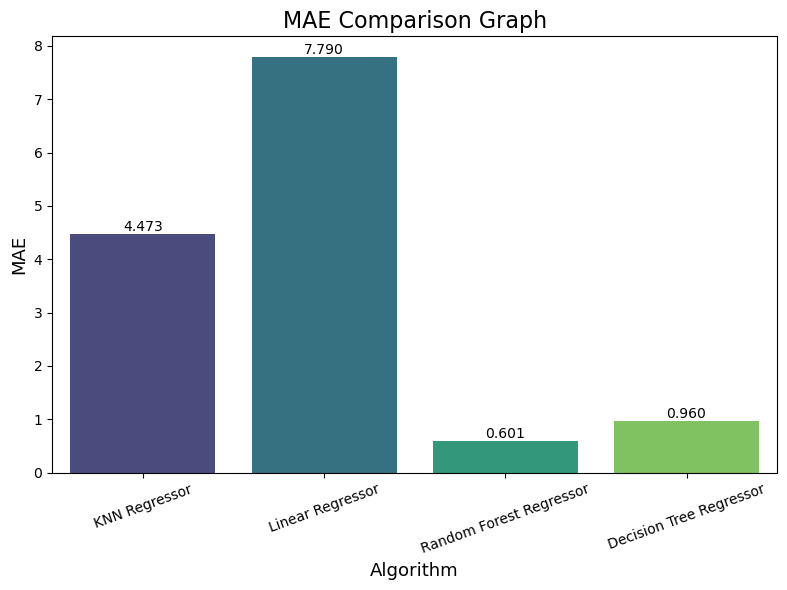

In [ ]:
plot_metric("MAE")

C:\Users\spoor\AppData\Local\Temp\ipykernel_15456\1157075884.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


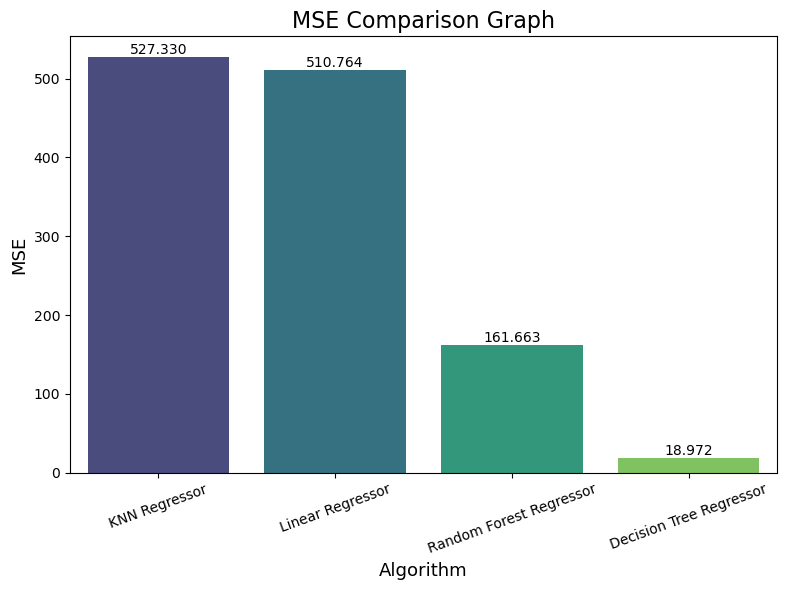

In [ ]:
plot_metric("MSE")

C:\Users\spoor\AppData\Local\Temp\ipykernel_15456\1157075884.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


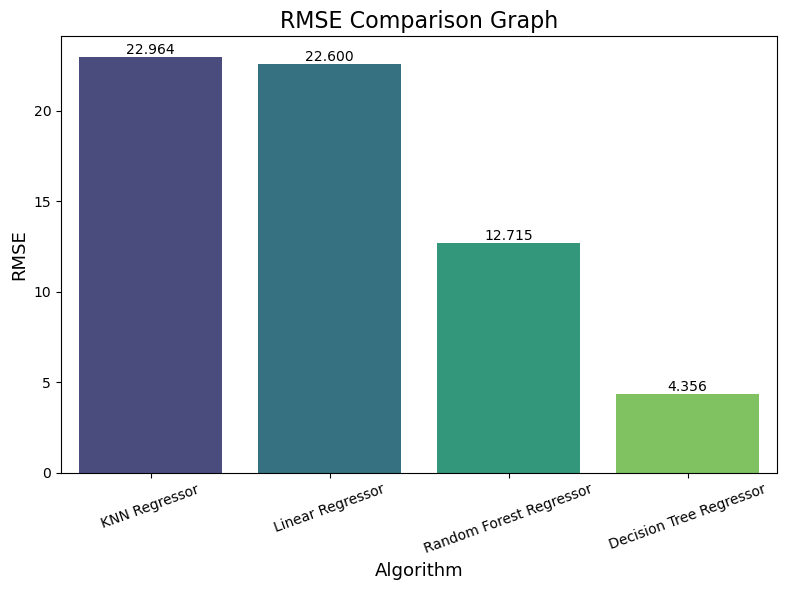

In [ ]:
plot_metric("RMSE")

C:\Users\spoor\AppData\Local\Temp\ipykernel_15456\1157075884.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


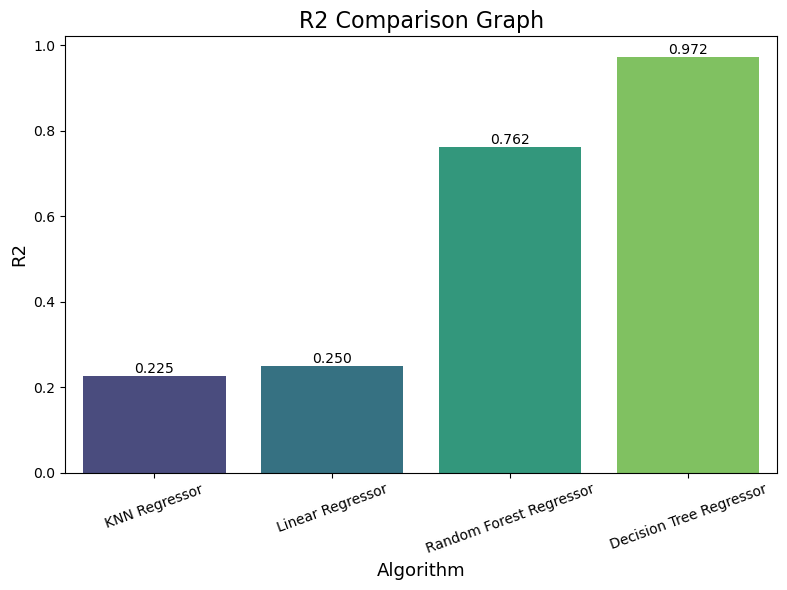

In [ ]:
plot_metric("R2")

# Test Data Prediction

In [ ]:
df = pd.read_csv(r"Instagram_dataset\test.csv")
df

,post_id,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,content_category
0,IG0000001,Reel,31627,7559,4530,6393,615036,1007750,1340,3,899,Home Feed,Technology
1,IG0000002,Photo,63206,3490,1680,6809,1237071,1345900,1351,20,805,Hashtags,Fitness
2,IG0000003,Reel,94373,3727,1761,8367,1127470,1305369,242,24,758,Reels Feed,Beauty
3,IG0000004,Reel,172053,7222,2875,9290,764030,897874,446,11,402,External,Music
4,IG0000005,Video,99646,2703,4444,9746,7004,495406,1905,8,155,Profile,Technology
5,IG0000006,Carousel,10500,7337,3601,5163,311157,381943,1448,12,904,Reels Feed,Photography
6,IG0000007,Carousel,193906,6326,4384,5581,277864,690698,904,21,701,Explore,Food
7,IG0000008,Carousel,27317,3289,2352,11684,1185935,1592082,400,27,894,Profile,Technology
8,IG0000009,Photo,90827,6557,570,13750,906114,1110667,236,13,739,Reels Feed,Beauty
9,IG0000010,Photo,67067,5988,3223,11741,1212435,1556489,1219,29,611,Hashtags,Music


In [ ]:
df['post_id'] = le.fit_transform(df['post_id'])
df['media_type'] = le.fit_transform(df['media_type'])
df['content_category'] = le.fit_transform(df['content_category'])
df['traffic_source'] = le.fit_transform(df['traffic_source'])

In [ ]:
cols_to_scale1 = [col for col in cols_to_scale if col != 'engagement_rate']

df[cols_to_scale1] = scaler.fit_transform(df[cols_to_scale1])

In [ ]:
df

,post_id,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,content_category
0,-1.647509,0.512989,-1.208986,1.097525,1.376490,-0.521554,-0.382135,-0.084057,0.634025,-1.643397,0.938619,0.246183,1.199593
1,-1.474087,-0.512989,-0.654777,-0.722848,-0.711821,-0.417200,0.961936,0.598295,0.651830,0.481147,0.562050,-0.369274,-0.833616
2,-1.300665,0.512989,-0.107799,-0.616820,-0.652469,-0.026377,0.725114,0.516508,-1.143252,0.981039,0.373765,1.477098,-1.240258
3,-1.127243,0.512989,1.255479,0.946760,0.163804,0.205157,-0.060194,-0.305776,-0.813047,-0.643612,-1.052391,-0.984732,0.386310
4,-0.953821,1.538968,-0.015258,-1.074933,1.313474,0.319545,-1.695948,-1.117915,1.548561,-1.018531,-2.041888,0.861640,1.199593
5,-0.780399,-1.538968,-1.579763,0.998208,0.695774,-0.830098,-1.038746,-1.346872,0.808839,-0.518639,0.958650,1.477098,0.792952
6,-0.606977,-1.538968,1.638997,0.545911,1.269510,-0.725243,-1.110684,-0.723836,-0.071706,0.606120,0.145420,-1.600189,-0.426974
7,-0.433555,-1.538968,-1.284626,-0.812770,-0.219419,0.805691,0.851443,1.095066,-0.887505,1.355959,0.918589,0.861640,1.199593
8,-0.260133,-0.512989,-0.170031,0.649254,-1.525163,1.323946,0.246816,0.123619,-1.152964,-0.393665,0.297650,1.477098,-1.240258
9,-0.086711,-0.512989,-0.587017,0.394698,0.418798,0.819989,0.908703,1.023243,0.438168,1.605905,-0.215125,-0.369274,0.386310


In [ ]:
model = 'model/dtr_regressor1.pkl'
dt_regressor = joblib.load(model)
predicted_engagement_rate = dt_regressor.predict(df)

C:\Users\spoor\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
df["pred_engagement"] = predicted_engagement_rate

In [ ]:
df

,post_id,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,content_category,pred_scaled,pred_engagement
0,-1.647509,0.512989,-1.208986,1.097525,1.376490,-0.521554,-0.382135,-0.084057,0.634025,-1.643397,0.938619,0.246183,1.199593,3.728322,3.728322
1,-1.474087,-0.512989,-0.654777,-0.722848,-0.711821,-0.417200,0.961936,0.598295,0.651830,0.481147,0.562050,-0.369274,-0.833616,5.653308,5.653308
2,-1.300665,0.512989,-0.107799,-0.616820,-0.652469,-0.026377,0.725114,0.516508,-1.143252,0.981039,0.373765,1.477098,-1.240258,7.055938,7.055938
3,-1.127243,0.512989,1.255479,0.946760,0.163804,0.205157,-0.060194,-0.305776,-0.813047,-0.643612,-1.052391,-0.984732,0.386310,17.091875,17.091875
4,-0.953821,1.538968,-0.015258,-1.074933,1.313474,0.319545,-1.695948,-1.117915,1.548561,-1.018531,-2.041888,0.861640,1.199593,20.388929,20.388929
5,-0.780399,-1.538968,-1.579763,0.998208,0.695774,-0.830098,-1.038746,-1.346872,0.808839,-0.518639,0.958650,1.477098,0.792952,5.088795,5.088795
6,-0.606977,-1.538968,1.638997,0.545911,1.269510,-0.725243,-1.110684,-0.723836,-0.071706,0.606120,0.145420,-1.600189,-0.426974,24.959000,24.959000
7,-0.433555,-1.538968,-1.284626,-0.812770,-0.219419,0.805691,0.851443,1.095066,-0.887505,1.355959,0.918589,0.861640,1.199593,2.320023,2.320023
8,-0.260133,-0.512989,-0.170031,0.649254,-1.525163,1.323946,0.246816,0.123619,-1.152964,-0.393665,0.297650,1.477098,-1.240258,7.880430,7.880430
9,-0.086711,-0.512989,-0.587017,0.394698,0.418798,0.819989,0.908703,1.023243,0.438168,1.605905,-0.215125,-0.369274,0.386310,4.527690,4.527690
